# Waveform evolution plot of $|\tilde{h}_+(f)|$

In [1]:
import numpy as np
import bilby
import logging
logging.getLogger('bilby').setLevel(logging.WARNING) # Or logging.ERROR
import matplotlib.pyplot as plt
# %matplotlib inline

size_axis_label = 13
size_tick_label = 11
size_legend_label = 12

C = 299792458.
G = 6.67408*1e-11
Mo = 1.989*1e30
Mpc = 3.086*1e22

## Short Inspiral: GW150914-like signal

In [2]:
injection_parameters = dict(mass_1 = 38.21699758702877, mass_2 = 32.20969716505654, eccentricity=0.1, a_1 = 0.4338995320657293, a_2 = 0.39888934269976206, tilt_1 = 1.6906449109686164, tilt_2 = 1.7730966571159301, phi_12 = 3.0382959521018726, phi_jl = 1.6881815480645899, luminosity_distance = 455.61617115135334, dec = -1.2190750471909269, ra = 1.7368337508407308, theta_jn = 2.69058100030177, psi = 1.4777795108631158, phase = 3.4883939708111518, geocent_time = 1126259642.413)

time_of_event = 1126259642.413
post_trigger_duration = 1.
duration = 4.0
analysis_start = time_of_event + post_trigger_duration - duration
sampling_frequency = 2048.

minimum_frequency = 20.0
maximum_frequency = 128.0

In [3]:
import lalsimulation as lalsim
print(lalsim.__file__)
print(lalsim.TaylorF2Ecch)

/Users/phurailatpamhemantakumar/phd/mypackages/lalsuite-install/lib/python3.12/site-packages/lalsimulation/__init__.py
120


/Users/phurailatpamhemantakumar/phd/mypackages/lalsuite-install/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [4]:
############# TF2Ecck waveform model ################
waveform_arguments = dict(waveform_approximant='TaylorF2Ecck',
                          reference_frequency=20., minimum_frequency=20.)

waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments)

ifos = bilby.gw.detector.InterferometerList(['L1', 'H1'])
for ifo in ifos:
    ifo.minimum_frequency = minimum_frequency
    ifo.maximum_frequency = maximum_frequency
ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=analysis_start)

ifos.inject_signal(waveform_generator=waveform_generator,
                   parameters=injection_parameters)
snrs = [ifo.meta_data["optimal_SNR"] for ifo in ifos]
print('net_snr = ',np.sqrt(np.sum([i ** 2 for i in snrs])))

net_snr =  72.12797984176967


In [5]:
############# TF2Ecch waveform model ################
waveform_arguments2 = dict(waveform_approximant='TaylorF2Ecch',
                          reference_frequency=20., minimum_frequency=20.)

waveform_generator2 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments2)

ifos2 = bilby.gw.detector.InterferometerList(['L1', 'H1'])
for ifo in ifos2:
    ifo.minimum_frequency = minimum_frequency
    ifo.maximum_frequency = maximum_frequency
ifos2.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=analysis_start)
    
ifos2.inject_signal(waveform_generator=waveform_generator2,
                   parameters=injection_parameters)

snrs = [ifo.meta_data["optimal_SNR"] for ifo in ifos2]
print('net_snr = ','net_snr = ',np.sqrt(np.sum([i ** 2 for i in snrs])))

net_snr =  net_snr =  73.547369648958


In [6]:
############# TF2Ecc waveform model ################
waveform_arguments3 = dict(waveform_approximant='TaylorF2Ecc',
                          reference_frequency=20., minimum_frequency=20., pn_phase_order=6, pn_tidal_order=0)

waveform_generator3 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments3)

minimum_frequency = 20.0
maximum_frequency = 128.0

ifos3 = bilby.gw.detector.InterferometerList(['L1', 'H1'])
for ifo in ifos3:
    ifo.minimum_frequency = minimum_frequency
    ifo.maximum_frequency = maximum_frequency
ifos3.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=analysis_start)

ifos3.inject_signal(waveform_generator=waveform_generator3,
                   parameters=injection_parameters)

snrs = [ifo.meta_data["optimal_SNR"] for ifo in ifos3]
print('net_snr = ',np.sqrt(np.sum([i ** 2 for i in snrs])))

net_snr =  73.00411753726159


In [7]:
############# TaylorF2 waveform model ################
waveform_arguments4 = dict(waveform_approximant='TaylorF2',
                          reference_frequency=20., minimum_frequency=20., pn_phase_order=6, pn_amplitude_order=0, pn_tidal_order=0)

waveform_generator4 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments4)

minimum_frequency = 20.0
maximum_frequency = 128.0

ifos4 = bilby.gw.detector.InterferometerList(['L1', 'H1'])
for ifo in ifos4:
    ifo.minimum_frequency = minimum_frequency
    ifo.maximum_frequency = maximum_frequency
ifos4.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=analysis_start)

ifos4.inject_signal(waveform_generator=waveform_generator4,
                   parameters=injection_parameters)

snrs = [ifo.meta_data["optimal_SNR"] for ifo in ifos4]
print('net_snr = ',np.sqrt(np.sum([i ** 2 for i in snrs])))

net_snr =  73.00411753726159


In [8]:
#to plot the frequency domain  
############# TF2Ecck waveform model ################
injection = ifos.inject_signal(waveform_generator=waveform_generator,
                   parameters=injection_parameters)
L1 = ifos[0]
L1_injection = injection[0]
idxs = L1.strain_data.frequency_mask  

############# TF2Ecch ################
injection2 = ifos2.inject_signal(waveform_generator=waveform_generator2,
                   parameters=injection_parameters)
L12 = ifos2[0]
L1_injection2 = injection2[0]
idxs2 = L12.strain_data.frequency_mask

############# TF2Ecc ################
injection3 = ifos3.inject_signal(waveform_generator=waveform_generator3,
                   parameters=injection_parameters)
L13 = ifos3[0]
L1_injection3 = injection3[0]
idxs3 = L13.strain_data.frequency_mask

############# TF2 ################
injection4 = ifos4.inject_signal(waveform_generator=waveform_generator4,
                   parameters=injection_parameters)
L14 = ifos4[0]
L1_injection4 = injection4[0]
idxs4 = L14.strain_data.frequency_mask

/Users/phurailatpamhemantakumar/anaconda3/envs/ler/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/phurailatpamhemantakumar/anaconda3/envs/ler/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


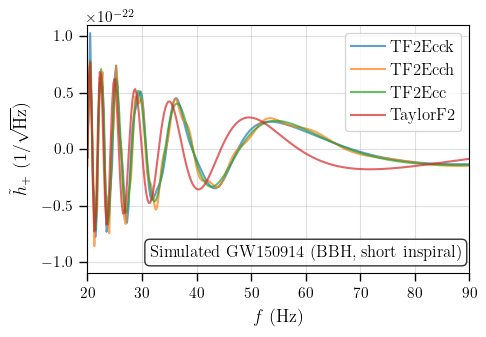

In [9]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": size_tick_label
})

fig, ax = plt.subplots(1, 1, facecolor='w', figsize=(5, 3.5))
ax.plot(L1.frequency_array[idxs],
          L1_injection["plus"][idxs],
          label="TF2Ecck", alpha=0.7)
ax.plot(L1.frequency_array[idxs],
          L1_injection2["plus"][idxs],
          label="TF2Ecch", alpha=0.7)
ax.plot(L1.frequency_array[idxs],
          L1_injection3["plus"][idxs],
          label="TF2Ecc", alpha=0.7)
ax.plot(L14.frequency_array[idxs4],
          L1_injection4["plus"][idxs4],
          label="TaylorF2", alpha=0.7)
          
ax.set_xlim(20, 90)
ax.set_ylim(-1.1e-22, 1.1e-22)
ax.set_xlabel(r"$f$ (Hz)", labelpad=6.0, fontsize=size_axis_label)
ax.set_ylabel(r"$\tilde{h}_+$ (1/$\sqrt{\rm Hz}$)", labelpad=8.0, fontsize=size_axis_label)

# Customize x-axis tick labels
# plt.xticks([20, 30, 40, 60, 100], ['20', '30', '40', '60', '100'])
ax.tick_params(axis="both", which="both", labelsize=size_tick_label, pad=4)

# Add a gray box behind the legend
legend = ax.legend(loc="upper right", bbox_to_anchor=(1, 1), facecolor='w', framealpha=0.8, frameon=True, fontsize=size_legend_label) 
legend.get_frame().set_facecolor('w')
legend.get_frame().set_alpha(0.8)
for text in legend.get_texts():
    text.set_color("k")

ax.grid(True, which="both", ls="-", alpha=0.4)
fig.set_size_inches(5, 3.5)
fig.tight_layout()
# plt.text(0.98, 0.95, "Simulated GW170817 (BNS, long inspiral)", 
#          transform=ax2.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='right',
#          bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
plt.text(0.98, 0.05, "Simulated GW150914 (BBH, short inspiral)", 
         transform=ax.transAxes, fontsize=12, verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
fig.savefig("real_hplus_gw150914.pdf")
plt.show()